# 94 — Match nodal individual events to Geode stack metadata

This notebook assigns individual nodal events to Geode stacked shot records.

For Geode surveys, Jochen's spreadsheet is the source-position truth. Nodal energy-derived source position is used as a diagnostic residual, not as the primary source location.

Matching is driven by corrected Geode stack timing windows:

- Geode stacked-file time = final trigger in stack
- stack window extends backwards from the corrected final-trigger time
- candidate nodal events must fall within that window and have a source-position estimate close to the spreadsheet source position

Inputs:

- `geode_events` from `92_build_geode_shot_catalog_from_excel.ipynb`
- `nodal_source_estimates` from `93_estimate_nodal_source_positions.ipynb`

Outputs/replaces:

- `geode_nodal_event_matches`
- `geode_nodal_stack_match_summary`
- `geode_nodal_unmatched_stacks`

## 1. Configuration

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"

OUT_ROOT = PROJECT_ROOT / "nodal_geode_match_exports"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Set one survey for focused testing, or None for all Geode surveys.
TARGET_SURVEY = None
# TARGET_SURVEY = "T1_1m_refraction"
# TARGET_SURVEY = "T1_streamer_masw"

SOURCE_TOLERANCE_M = 4.0
TIME_MARGIN_BEFORE_S = 0.0
TIME_MARGIN_AFTER_S = 0.0

AUTO_ACCEPT_MAX_SOURCE_RESID_M = 3.0
AUTO_ACCEPT_MAX_ABS_FINAL_TIME_S = 180.0

WRITE_TABLES = True

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)
print("TARGET_SURVEY:", TARGET_SURVEY)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports
TARGET_SURVEY: None


## 2. Load catalog tables

In [2]:
conn = sqlite3.connect(CATALOG_DB)

tables = pd.read_sql(
    '''
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
    ''',
    conn,
)
display(tables)

required = ["geode_events", "nodal_source_estimates", "shot_events", "shot_gather_files", "trace_index"]
missing = [t for t in required if t not in set(tables["name"])]
if missing:
    raise RuntimeError(f"Missing required tables: {missing}. Run 90, 92, and 93 first.")

geode_events = pd.read_sql("SELECT * FROM geode_events", conn)
nodal_est = pd.read_sql("SELECT * FROM nodal_source_estimates", conn)
shot_events = pd.read_sql("SELECT * FROM shot_events WHERE instrument_system='nodal'", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files WHERE instrument_system='nodal'", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index WHERE instrument_system='nodal'", conn)

print("geode_events:", len(geode_events))
print("nodal_source_estimates:", len(nodal_est))
print("nodal shot_events:", len(shot_events))
print("shot_gather_files:", len(shot_gather_files))
print("trace_index:", len(trace_index))

,name
0,geode_events
1,geode_time_models
2,nodal_geode_stack_candidates
3,nodal_geode_stack_summary
4,nodal_source_estimates
5,picks
6,processing_errors
7,processing_runs
8,receiver_geometry
9,shot_events


geode_events: 327
nodal_source_estimates: 3436
nodal shot_events: 3436
shot_gather_files: 3436
trace_index: 338580


## 3. Normalize times and numeric fields

In [3]:
for col in ["stack_start_utc", "stack_end_utc", "geode_final_trigger_time_utc"]:
    if col in geode_events.columns:
        geode_events[col.replace("_utc", "_dt")] = pd.to_datetime(
            geode_events[col],
            errors="coerce",
            utc=True,
        )

geode_events["source_x_m"] = pd.to_numeric(geode_events["source_x_m"], errors="coerce")
geode_events["file_no"] = pd.to_numeric(geode_events["file_no"], errors="coerce")
geode_events["n_stack_shots"] = pd.to_numeric(geode_events["n_stack_shots"], errors="coerce")

nodal_est["event_time_dt"] = pd.to_datetime(nodal_est["event_time_utc"], errors="coerce", utc=True)
nodal_est["estimated_source_x_m"] = pd.to_numeric(nodal_est["estimated_source_x_m"], errors="coerce")

geode_use = geode_events.dropna(
    subset=["stack_start_dt", "stack_end_dt", "source_x_m"]
).copy()
nodal_use = nodal_est.dropna(
    subset=["event_time_dt", "estimated_source_x_m"]
).copy()

if TARGET_SURVEY is not None:
    geode_use = geode_use[geode_use["survey"].astype(str).eq(TARGET_SURVEY)].copy()

print("usable geode_events:", len(geode_use))
print("usable nodal source estimates:", len(nodal_use))

display(geode_use.groupby(["survey", "line"], dropna=False).size().reset_index(name="n_geode_stacks"))
display(nodal_use.groupby("timewindow_label", dropna=False).size().reset_index(name="n_nodal_events"))

usable geode_events: 98
usable nodal source estimates: 3431


,survey,line,n_geode_stacks
0,T1_1m_refraction,T1,42
1,T1_2m_refraction,T1,42
2,T4_1m_refraction,T4,14


,timewindow_label,n_nodal_events
0,T1_N1_Streamer,532
1,T1_N2_Nodal1,1374
2,T1_N2_Nodal2,81
3,T1_N2_Refraction1m,429
4,T1_N2_Refraction2m,450
5,T1_N3_Nodal3,43
6,T3_N4_Refraction1am,522


## 4. Candidate matching logic

In [4]:
def score_match(time_from_final_s, source_x_residual_m, in_stack_window=True):
    '''Higher is better. Uses source-position residual as diagnostic and ranking aid.'''
    score = 0.0

    if in_stack_window:
        score += 10.0

    if np.isfinite(source_x_residual_m):
        score += max(0.0, 5.0 - abs(source_x_residual_m))

    # Valid stack members are usually negative time_from_final_s because the
    # Geode time is the final trigger in the stack.
    if np.isfinite(time_from_final_s):
        score += max(0.0, 5.0 - abs(time_from_final_s) / 30.0)

    return float(score)


def classify_match(source_x_residual_m, time_from_final_s):
    if not np.isfinite(source_x_residual_m):
        return "review_no_source_estimate"
    if (
        abs(source_x_residual_m) <= AUTO_ACCEPT_MAX_SOURCE_RESID_M
        and abs(time_from_final_s) <= AUTO_ACCEPT_MAX_ABS_FINAL_TIME_S
    ):
        return "accepted_auto"
    if abs(source_x_residual_m) <= SOURCE_TOLERANCE_M:
        return "review_position_ok"
    return "rejected_position"

## 5. Build Geode↔nodal event candidate table

In [5]:
rows = []

for _, g in geode_use.iterrows():

    start = g["stack_start_dt"] - pd.to_timedelta(TIME_MARGIN_BEFORE_S, unit="s")
    end = g["stack_end_dt"] + pd.to_timedelta(TIME_MARGIN_AFTER_S, unit="s")
    source_truth = float(g["source_x_m"])

    cand = nodal_use.copy()

    # Prefer expected nodal time window from 92 metadata.
    tw = g.get("nodal_timewindow_label")
    if isinstance(tw, str) and tw and tw.lower() not in ["none", "nan"]:
        cand_tw = cand[cand["timewindow_label"].astype(str).eq(tw)].copy()
        if len(cand_tw):
            cand = cand_tw

    # Same line where available.
    if isinstance(g.get("line"), str) and "line" in cand.columns:
        same_line = cand[cand["line"].astype(str).eq(str(g["line"]))].copy()
        if len(same_line):
            cand = same_line

    # Time window is primary for Geode surveys.
    cand = cand[
        (cand["event_time_dt"] >= start) &
        (cand["event_time_dt"] <= end)
    ].copy()

    if cand.empty:
        continue

    cand["source_x_truth_m"] = source_truth
    cand["source_x_residual_m"] = cand["estimated_source_x_m"] - source_truth
    cand["abs_source_x_residual_m"] = cand["source_x_residual_m"].abs()

    # Source estimate is a diagnostic filter/ranking aid.
    cand = cand[cand["abs_source_x_residual_m"] <= SOURCE_TOLERANCE_M].copy()

    for _, n in cand.iterrows():
        final_dt = g.get("geode_final_trigger_time_dt", pd.NaT)
        time_from_final_s = (
            (n["event_time_dt"] - final_dt).total_seconds()
            if pd.notna(final_dt)
            else np.nan
        )

        status = classify_match(n["source_x_residual_m"], time_from_final_s)
        score = score_match(time_from_final_s, n["source_x_residual_m"], True)

        rows.append({
            "geode_event_id": g["geode_event_id"],
            "geode_survey": g["survey"],
            "line": g["line"],
            "file_no": int(g["file_no"]) if np.isfinite(g["file_no"]) else None,
            "source_type": g.get("source_type"),
            "n_stack_shots": int(g["n_stack_shots"]) if np.isfinite(g["n_stack_shots"]) else None,
            "source_x_truth_m": source_truth,
            "geode_final_trigger_time_utc": g.get("geode_final_trigger_time_utc"),
            "stack_start_utc": g.get("stack_start_utc"),
            "stack_end_utc": g.get("stack_end_utc"),
            "geode_clock_correction_s": g.get("geode_clock_correction_s"),
            "geode_file_time_meaning": g.get("geode_file_time_meaning"),

            "nodal_event_id": n["event_id"],
            "nodal_timewindow_label": n["timewindow_label"],
            "nodal_event_time_utc": n["event_time_utc"],
            "nodal_event_time_method": n.get("event_time_method"),
            "estimated_source_x_m": n["estimated_source_x_m"],
            "source_x_method": n.get("source_x_method"),
            "source_x_residual_m": n["source_x_residual_m"],
            "abs_source_x_residual_m": n["abs_source_x_residual_m"],
            "time_from_final_trigger_s": time_from_final_s,
            "match_score": score,
            "match_status": status,
            "accepted": status.startswith("accepted"),
            "mseed_path": n.get("mseed_path"),
            "top_energy_receivers_json": n.get("top_energy_receivers_json"),
        })

matches = pd.DataFrame(rows)

print("candidate matches:", len(matches))
if len(matches):
    display(matches.head())
    display(matches["match_status"].value_counts(dropna=False))
else:
    print("No matches found.")

candidate matches: 422


,geode_event_id,geode_survey,line,file_no,source_type,n_stack_shots,source_x_truth_m,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,...,estimated_source_x_m,source_x_method,source_x_residual_m,abs_source_x_residual_m,time_from_final_trigger_s,match_score,match_status,accepted,mseed_path,top_energy_receivers_json
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,...,83.821893,weighted_top3_energy_hp25,-0.678107,0.678107,-46.490,17.772227,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
1,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,...,83.970530,weighted_top3_energy_hp25,-0.529470,0.529470,-37.076,18.234664,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
2,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,...,83.864182,weighted_top3_energy_hp25,-0.635818,0.635818,-30.486,18.347982,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
3,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,...,84.035583,weighted_top3_energy_hp25,-0.464417,0.464417,-23.902,18.738850,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."
4,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,hammer,9,84.5,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,...,84.031521,weighted_top3_energy_hp25,-0.468479,0.468479,-17.096,18.961654,accepted_auto,True,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,"[{""seed_id"": ""T1.08405.N2.DPZ"", ""station"": ""08..."


match_status
accepted_auto         410
review_position_ok     12
Name: count, dtype: int64

## 6. Stack-level summary

In [6]:
if len(matches):
    stack_summary = (
        matches
        .groupby(
            [
                "geode_event_id",
                "geode_survey",
                "line",
                "file_no",
                "source_x_truth_m",
                "source_type",
                "n_stack_shots",
            ],
            dropna=False,
        )
        .agg(
            n_candidate_events=("nodal_event_id", "count"),
            n_accepted_auto=("accepted", "sum"),
            first_nodal_time_utc=("nodal_event_time_utc", "min"),
            last_nodal_time_utc=("nodal_event_time_utc", "max"),
            median_source_x_residual_m=("source_x_residual_m", "median"),
            median_abs_source_x_residual_m=("abs_source_x_residual_m", "median"),
            min_time_from_final_s=("time_from_final_trigger_s", "min"),
            max_time_from_final_s=("time_from_final_trigger_s", "max"),
            best_match_score=("match_score", "max"),
        )
        .reset_index()
        .sort_values(["geode_survey", "file_no", "source_x_truth_m"])
    )
else:
    stack_summary = pd.DataFrame()

display(stack_summary.head(100))

,geode_event_id,geode_survey,line,file_no,source_x_truth_m,source_type,n_stack_shots,n_candidate_events,n_accepted_auto,first_nodal_time_utc,last_nodal_time_utc,median_source_x_residual_m,median_abs_source_x_residual_m,min_time_from_final_s,max_time_from_final_s,best_match_score
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,6,6,2026-05-18T16:07:44.010000+00:00,2026-05-18T16:08:30.714000+00:00,-0.520314,0.520314,-46.490,0.214,19.481708
1,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,3008,88.5,hammer,9,3,3,2026-05-18T16:18:11.590000+00:00,2026-05-18T16:18:25.676000+00:00,-0.158460,0.158460,-20.910,-6.824,19.614074
2,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,3009,90.5,hammer,9,7,7,2026-05-18T16:20:09.242000+00:00,2026-05-18T16:20:52.060000+00:00,1.512838,1.512838,-42.258,0.560,18.479370
3,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,3010,92.5,hammer,10,2,2,2026-05-18T16:25:40.704000+00:00,2026-05-18T16:25:50.720000+00:00,-0.369446,0.369446,-42.796,-32.780,18.536152
4,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,3011,94.5,hammer,9,6,6,2026-05-18T16:35:47.448000+00:00,2026-05-18T16:36:33.668000+00:00,-0.052922,0.076996,-46.052,0.168,19.919853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,GEODE_T1_2M_REFRACTION_F3076,T1_2m_refraction,T1,3076,159.0,hammer,10,7,7,2026-05-18T21:59:43.312000+00:00,2026-05-18T22:00:33.988000+00:00,1.000729,1.000729,-50.188,0.488,18.983005
63,GEODE_T1_2M_REFRACTION_F3077,T1_2m_refraction,T1,3077,163.0,hammer,10,4,4,2026-05-18T22:03:14.028000+00:00,2026-05-18T22:04:00.998000+00:00,0.585681,0.585681,-46.472,0.498,19.367319
64,GEODE_T1_2M_REFRACTION_F3079,T1_2m_refraction,T1,3079,171.0,hammer,10,1,1,2026-05-18T22:10:10.378000+00:00,2026-05-18T22:10:10.378000+00:00,-2.732350,2.732350,-23.122,-23.122,16.496917
65,GEODE_T1_2M_REFRACTION_F3081,T1_2m_refraction,T1,3081,179.0,hammer,10,4,0,2026-05-18T22:29:18.598000+00:00,2026-05-18T22:29:51.860000+00:00,-3.591594,3.591594,-53.902,-20.640,15.717140


## 7. QC: which Geode stacks were missed?

In [7]:
if len(stack_summary):
    matched_geode_ids = set(stack_summary["geode_event_id"].astype(str))
else:
    matched_geode_ids = set()

missed = geode_use[~geode_use["geode_event_id"].astype(str).isin(matched_geode_ids)].copy()

print("Geode stacks:", len(geode_use))
print("Matched stacks:", len(matched_geode_ids))
print("Missed stacks:", len(missed))

cols = [
    "geode_event_id",
    "survey",
    "line",
    "file_no",
    "source_x_m",
    "geode_final_trigger_time_utc",
    "stack_start_utc",
    "stack_end_utc",
    "nodal_timewindow_label",
]
display(missed[[c for c in cols if c in missed.columns]].head(50))

Geode stacks: 98
Matched stacks: 67
Missed stacks: 31


,geode_event_id,survey,line,file_no,source_x_m,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,nodal_timewindow_label
4,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,3005,82.5,2026-05-18T16:03:42.500000+00:00,2026-05-18T16:02:54.500000+00:00,2026-05-18T16:03:44.500000+00:00,T1_N2_Refraction1m
6,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,T1,3007,86.5,2026-05-18T16:13:29.500000+00:00,2026-05-18T16:12:41.500000+00:00,2026-05-18T16:13:31.500000+00:00,T1_N2_Refraction1m
14,GEODE_T1_1M_REFRACTION_F3015,T1_1m_refraction,T1,3015,102.5,2026-05-18T16:55:30.500000+00:00,2026-05-18T16:54:42.500000+00:00,2026-05-18T16:55:32.500000+00:00,T1_N2_Refraction1m
46,GEODE_T1_2M_REFRACTION_F3047,T1_2m_refraction,T1,3047,43.0,2026-05-18T20:18:32.500000+00:00,2026-05-18T20:17:38.500000+00:00,2026-05-18T20:18:34.500000+00:00,T1_N2_Refraction2m
47,GEODE_T1_2M_REFRACTION_F3048,T1_2m_refraction,T1,3048,47.0,2026-05-18T20:21:32.500000+00:00,2026-05-18T20:20:38.500000+00:00,2026-05-18T20:21:34.500000+00:00,T1_N2_Refraction2m
48,GEODE_T1_2M_REFRACTION_F3049,T1_2m_refraction,T1,3049,51.0,2026-05-18T20:26:04.500000+00:00,2026-05-18T20:25:10.500000+00:00,2026-05-18T20:26:06.500000+00:00,T1_N2_Refraction2m
49,GEODE_T1_2M_REFRACTION_F3050,T1_2m_refraction,T1,3050,55.0,2026-05-18T20:30:07.500000+00:00,2026-05-18T20:29:13.500000+00:00,2026-05-18T20:30:09.500000+00:00,T1_N2_Refraction2m
50,GEODE_T1_2M_REFRACTION_F3051,T1_2m_refraction,T1,3051,59.0,2026-05-18T20:33:06.500000+00:00,2026-05-18T20:32:12.500000+00:00,2026-05-18T20:33:08.500000+00:00,T1_N2_Refraction2m
51,GEODE_T1_2M_REFRACTION_F3052,T1_2m_refraction,T1,3052,63.0,2026-05-18T20:36:27.500000+00:00,2026-05-18T20:35:33.500000+00:00,2026-05-18T20:36:29.500000+00:00,T1_N2_Refraction2m
77,GEODE_T1_2M_REFRACTION_F3078,T1_2m_refraction,T1,3078,167.0,2026-05-18T22:06:27.500000+00:00,2026-05-18T22:05:33.500000+00:00,2026-05-18T22:06:29.500000+00:00,T1_N2_Refraction2m


## 8. Write match tables and CSV exports

In [8]:
if WRITE_TABLES:
    matches.to_sql("geode_nodal_event_matches", conn, if_exists="replace", index=False)
    stack_summary.to_sql("geode_nodal_stack_match_summary", conn, if_exists="replace", index=False)
    missed.to_sql("geode_nodal_unmatched_stacks", conn, if_exists="replace", index=False)
    conn.commit()

matches.to_csv(OUT_ROOT / "geode_nodal_event_matches.csv", index=False)
stack_summary.to_csv(OUT_ROOT / "geode_nodal_stack_match_summary.csv", index=False)
missed.to_csv(OUT_ROOT / "geode_nodal_unmatched_stacks.csv", index=False)

print("Wrote outputs to:", OUT_ROOT)
if WRITE_TABLES:
    print("Wrote SQLite tables:")
    print("  geode_nodal_event_matches")
    print("  geode_nodal_stack_match_summary")
    print("  geode_nodal_unmatched_stacks")

Wrote outputs to: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports
Wrote SQLite tables:
  geode_nodal_event_matches
  geode_nodal_stack_match_summary
  geode_nodal_unmatched_stacks


## 9. QC plot: nodal estimates, Geode stack windows, accepted matches

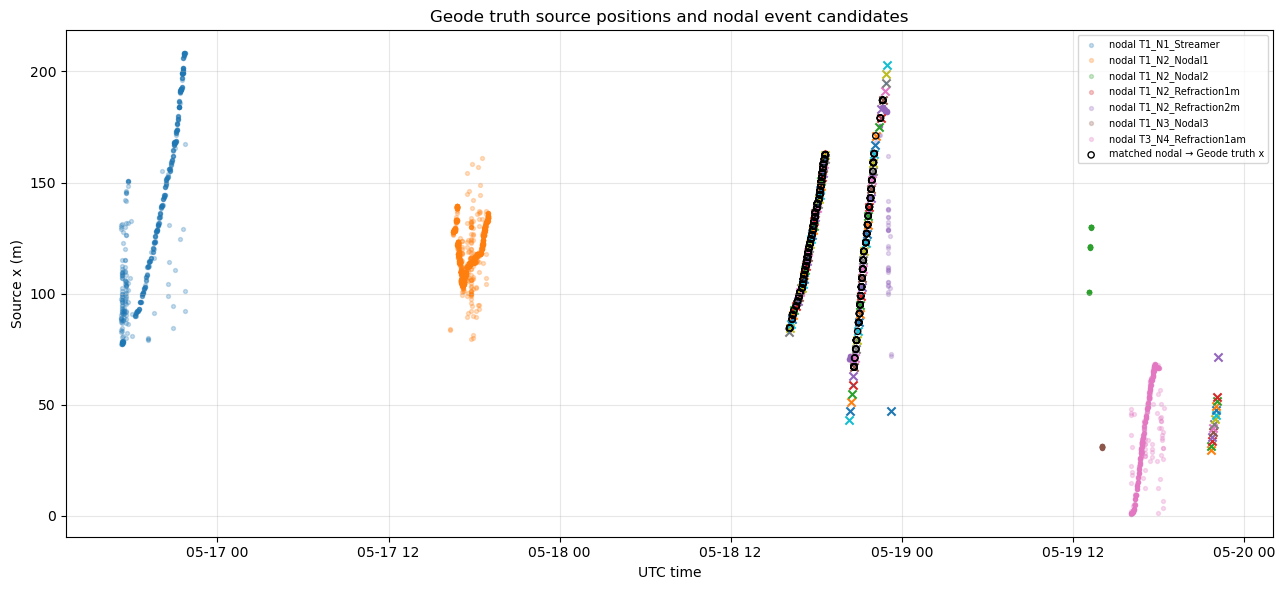

In [9]:
plot_n = nodal_use.copy()
plot_g = geode_use.copy()

fig, ax = plt.subplots(figsize=(13, 6))

# Raw nodal estimates.
for label, sub in plot_n.dropna(subset=["event_time_dt", "estimated_source_x_m"]).groupby("timewindow_label"):
    ax.scatter(
        sub["event_time_dt"],
        sub["estimated_source_x_m"],
        s=8,
        alpha=0.25,
        label=f"nodal {label}",
    )

# Geode stack windows and final trigger times.
for _, g in plot_g.dropna(subset=["stack_start_dt", "stack_end_dt", "source_x_m"]).iterrows():
    ax.hlines(g["source_x_m"], g["stack_start_dt"], g["stack_end_dt"], linewidth=2, alpha=0.8)
    if pd.notna(g.get("geode_final_trigger_time_dt", pd.NaT)):
        ax.scatter(
            [g["geode_final_trigger_time_dt"]],
            [g["source_x_m"]],
            marker="x",
            s=35,
        )

# Accepted or review-position-ok candidate matches.
if len(matches):
    m = matches[matches["match_status"].isin(["accepted_auto", "review_position_ok"])].copy()
    m["nodal_dt"] = pd.to_datetime(m["nodal_event_time_utc"], errors="coerce", utc=True)
    ax.scatter(
        m["nodal_dt"],
        m["source_x_truth_m"],
        s=20,
        marker="o",
        facecolors="none",
        edgecolors="black",
        label="matched nodal → Geode truth x",
    )

ax.set_title("Geode truth source positions and nodal event candidates")
ax.set_xlabel("UTC time")
ax.set_ylabel("Source x (m)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

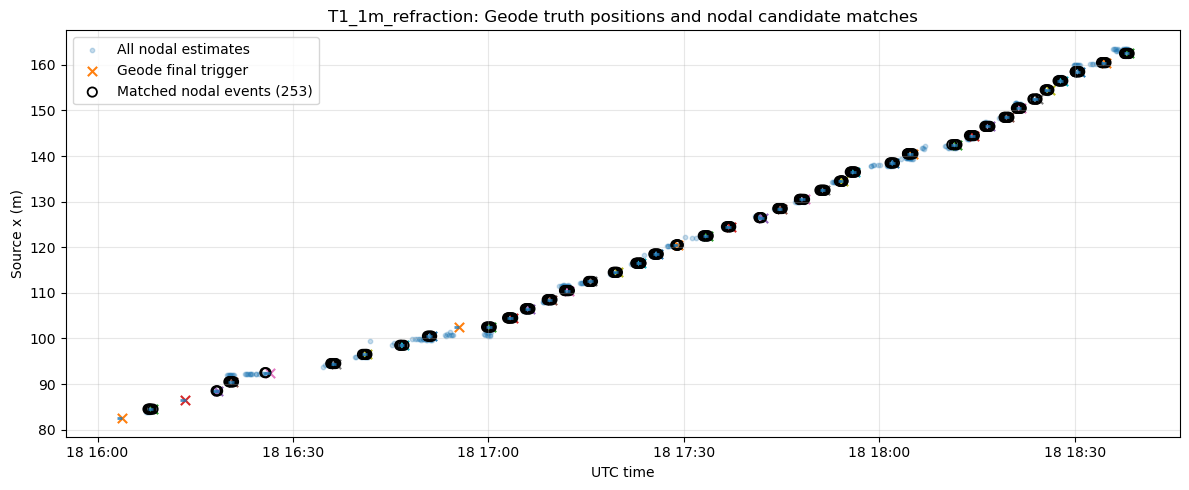


T1_1m_refraction
Geode stacks: 42
Matched nodal events: 253


,geode_event_id,file_no,source_x_truth_m,nodal_event_id,estimated_source_x_m,source_x_residual_m,time_from_final_trigger_s,match_status
0,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00003,83.821893,-0.678107,-46.490,accepted_auto
1,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00004,83.970530,-0.529470,-37.076,accepted_auto
2,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00005,83.864182,-0.635818,-30.486,accepted_auto
3,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00006,84.035583,-0.464417,-23.902,accepted_auto
4,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00007,84.031521,-0.468479,-17.096,accepted_auto
5,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,T1_N2_Refraction1m_T1_N2_E00008,83.988841,-0.511159,0.214,accepted_auto
6,GEODE_T1_1M_REFRACTION_F3008,3008,88.5,T1_N2_Refraction1m_T1_N2_E00009,88.409551,-0.090449,-20.910,accepted_auto
7,GEODE_T1_1M_REFRACTION_F3008,3008,88.5,T1_N2_Refraction1m_T1_N2_E00010,88.325117,-0.174883,-13.194,accepted_auto
8,GEODE_T1_1M_REFRACTION_F3008,3008,88.5,T1_N2_Refraction1m_T1_N2_E00011,88.341540,-0.158460,-6.824,accepted_auto
9,GEODE_T1_1M_REFRACTION_F3009,3009,90.5,T1_N2_Refraction1m_T1_N2_E00014,92.024162,1.524162,-42.258,accepted_auto


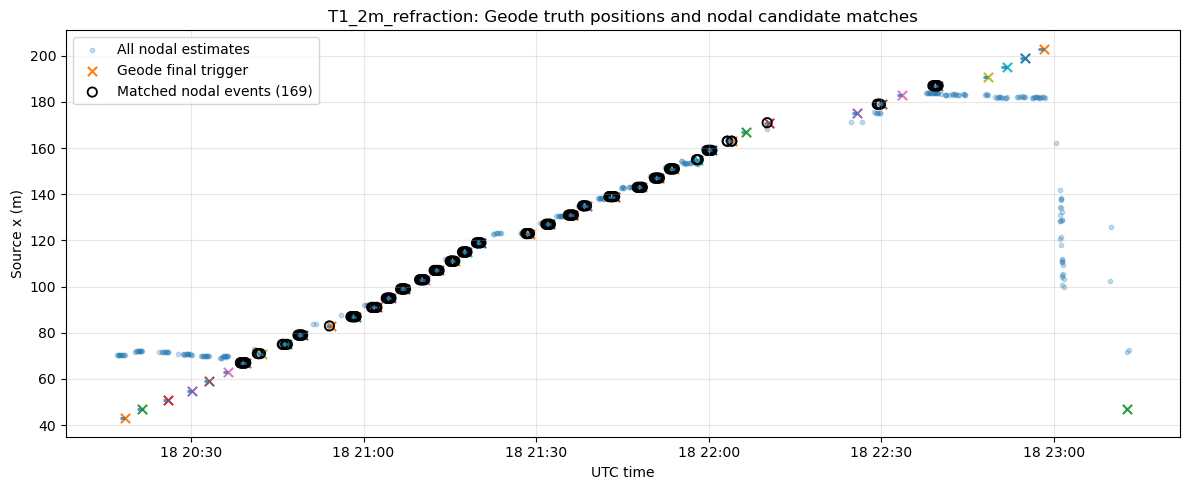


T1_2m_refraction
Geode stacks: 42
Matched nodal events: 169


,geode_event_id,file_no,source_x_truth_m,nodal_event_id,estimated_source_x_m,source_x_residual_m,time_from_final_trigger_s,match_status
253,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00068,68.239038,1.239038,-53.282,accepted_auto
254,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00069,68.239042,1.239042,-52.968,accepted_auto
255,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00070,68.226176,1.226176,-44.560,accepted_auto
256,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00071,68.226177,1.226177,-44.350,accepted_auto
257,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00072,68.209120,1.209120,-35.962,accepted_auto
258,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00073,68.209156,1.209156,-35.660,accepted_auto
259,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00074,68.206406,1.206406,-25.916,accepted_auto
260,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00075,68.206407,1.206407,-25.706,accepted_auto
261,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00076,68.233885,1.233885,-17.160,accepted_auto
262,GEODE_T1_2M_REFRACTION_F3053,3053,67.0,T1_N2_Refraction2m_T1_N2_E00077,68.226754,1.226754,-8.308,accepted_auto


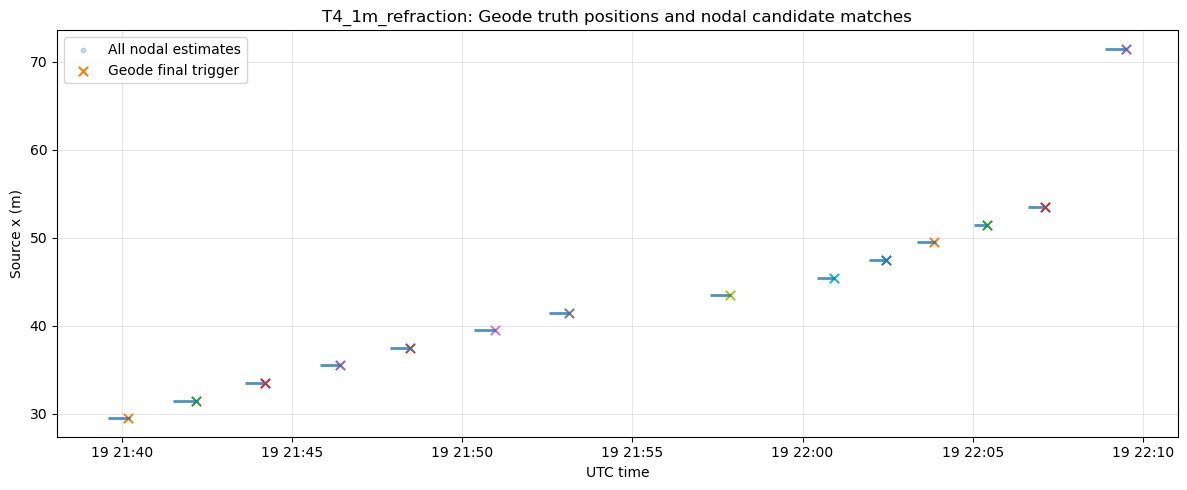


T4_1m_refraction
Geode stacks: 14
Matched nodal events: 0


In [11]:
# One figure per Geode survey
for survey, gsub in geode_use.groupby("survey"):

    tws = gsub["nodal_timewindow_label"].dropna().astype(str).unique()
    nsub = nodal_use[nodal_use["timewindow_label"].astype(str).isin(tws)].copy()

    msub = matches[matches["geode_survey"].astype(str).eq(survey)].copy() if len(matches) else pd.DataFrame()

    fig, ax = plt.subplots(figsize=(12, 5))

    # Raw nodal estimates
    ax.scatter(
        nsub["event_time_dt"],
        nsub["estimated_source_x_m"],
        s=10,
        alpha=0.25,
        label="All nodal estimates",
    )

    # Geode truth stack windows
    for _, g in gsub.iterrows():
        ax.hlines(
            g["source_x_m"],
            g["stack_start_dt"],
            g["stack_end_dt"],
            linewidth=2,
            alpha=0.8,
        )
        ax.scatter(
            g["geode_final_trigger_time_dt"],
            g["source_x_m"],
            marker="x",
            s=45,
            label="Geode final trigger" if _ == gsub.index[0] else None,
        )

    # Matched nodal events
    if len(msub):
        msub["nodal_dt"] = pd.to_datetime(msub["nodal_event_time_utc"], errors="coerce", utc=True)

        ax.scatter(
            msub["nodal_dt"],
            msub["source_x_truth_m"],
            s=45,
            facecolors="none",
            edgecolors="black",
            linewidths=1.3,
            label=f"Matched nodal events ({len(msub)})",
        )

    ax.set_title(f"{survey}: Geode truth positions and nodal candidate matches")
    ax.set_xlabel("UTC time")
    ax.set_ylabel("Source x (m)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{survey}")
    print("Geode stacks:", len(gsub))
    print("Matched nodal events:", len(msub))
    if len(msub):
        display(
            msub[
                [
                    "geode_event_id",
                    "file_no",
                    "source_x_truth_m",
                    "nodal_event_id",
                    "estimated_source_x_m",
                    "source_x_residual_m",
                    "time_from_final_trigger_s",
                    "match_status",
                ]
            ].head(30)
        )

## 10. Focused table for one survey

In [10]:
if len(stack_summary):
    survey_counts = stack_summary.groupby("geode_survey").agg(
        n_stacks=("geode_event_id", "count"),
        total_candidates=("n_candidate_events", "sum"),
        total_auto_accepted=("n_accepted_auto", "sum"),
    ).reset_index()
else:
    survey_counts = pd.DataFrame()

display(survey_counts)

# Uncomment for focused inspection:
# display(stack_summary[stack_summary["geode_survey"].eq("T1_1m_refraction")].head(100))
# display(matches[matches["geode_survey"].eq("T1_1m_refraction")].head(100))

,geode_survey,n_stacks,total_candidates,total_auto_accepted
0,T1_1m_refraction,39,253,253
1,T1_2m_refraction,28,169,157


In [12]:
match_coverage = (
    matches
    .groupby(["geode_survey", "geode_event_id", "file_no", "source_x_truth_m"], dropna=False)
    .agg(
        n_matches=("nodal_event_id", "count"),
        n_accepted=("accepted", "sum"),
        median_abs_dx_m=("abs_source_x_residual_m", "median"),
        min_time_from_final_s=("time_from_final_trigger_s", "min"),
        max_time_from_final_s=("time_from_final_trigger_s", "max"),
    )
    .reset_index()
    .sort_values(["geode_survey", "file_no"])
)

display(match_coverage)

,geode_survey,geode_event_id,file_no,source_x_truth_m,n_matches,n_accepted,median_abs_dx_m,min_time_from_final_s,max_time_from_final_s
0,T1_1m_refraction,GEODE_T1_1M_REFRACTION_F3006,3006,84.5,6,6,0.520314,-46.490,0.214
1,T1_1m_refraction,GEODE_T1_1M_REFRACTION_F3008,3008,88.5,3,3,0.158460,-20.910,-6.824
2,T1_1m_refraction,GEODE_T1_1M_REFRACTION_F3009,3009,90.5,7,7,1.512838,-42.258,0.560
3,T1_1m_refraction,GEODE_T1_1M_REFRACTION_F3010,3010,92.5,2,2,0.369446,-42.796,-32.780
4,T1_1m_refraction,GEODE_T1_1M_REFRACTION_F3011,3011,94.5,6,6,0.076996,-46.052,0.168
...,...,...,...,...,...,...,...,...,...
62,T1_2m_refraction,GEODE_T1_2M_REFRACTION_F3076,3076,159.0,7,7,1.000729,-50.188,0.488
63,T1_2m_refraction,GEODE_T1_2M_REFRACTION_F3077,3077,163.0,4,4,0.585681,-46.472,0.498
64,T1_2m_refraction,GEODE_T1_2M_REFRACTION_F3079,3079,171.0,1,1,2.732350,-23.122,-23.122
65,T1_2m_refraction,GEODE_T1_2M_REFRACTION_F3081,3081,179.0,4,0,3.591594,-53.902,-20.640


In [13]:
display(geode_events[geode_events["survey"].astype(str).str.contains("streamer", case=False, na=False)][
    ["geode_event_id", "survey", "line", "source_x_m",
     "geode_laptop_time_raw", "geode_clock_correction_s",
     "geode_final_trigger_time_utc", "stack_start_utc", "stack_end_utc",
     "nodal_timewindow_label"]
].head(20))

,geode_event_id,survey,line,source_x_m,geode_laptop_time_raw,geode_clock_correction_s,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,nodal_timewindow_label
88,GEODE_T1_STREAMER_MASW_F1001,T1_streamer_masw,T1,87.0,None,14067.0,None,None,None,T1_N1_Streamer
89,GEODE_T1_STREAMER_MASW_F1002,T1_streamer_masw,T1,88.5,None,14067.0,None,None,None,T1_N1_Streamer
90,GEODE_T1_STREAMER_MASW_F1003,T1_streamer_masw,T1,90.0,None,14067.0,None,None,None,T1_N1_Streamer
91,GEODE_T1_STREAMER_MASW_F1004,T1_streamer_masw,T1,91.5,None,14067.0,None,None,None,T1_N1_Streamer
92,GEODE_T1_STREAMER_MASW_F1005,T1_streamer_masw,T1,93.0,None,14067.0,None,None,None,T1_N1_Streamer
93,GEODE_T1_STREAMER_MASW_F1006,T1_streamer_masw,T1,94.5,None,14067.0,None,None,None,T1_N1_Streamer
94,GEODE_T1_STREAMER_MASW_F1007,T1_streamer_masw,T1,96.0,None,14067.0,None,None,None,T1_N1_Streamer
95,GEODE_T1_STREAMER_MASW_F1008,T1_streamer_masw,T1,97.5,None,14067.0,None,None,None,T1_N1_Streamer
96,GEODE_T1_STREAMER_MASW_F1009,T1_streamer_masw,T1,99.0,None,14067.0,None,None,None,T1_N1_Streamer
97,GEODE_T1_STREAMER_MASW_F1010,T1_streamer_masw,T1,100.5,None,14067.0,None,None,None,T1_N1_Streamer
